# Appendix Figure: TKGU Distribution across Deltas

Produces `tkgu_distribution_deltas.pdf`: stacked bar chart showing the distribution
of TKGU operations across KG deltas (1-5 weeks) for complete dataset and subsampled test set.

**Data sources:**
- Subsampled test set: from the refactored `WikiEvalResult` pkl
- Complete dataset: from old pipeline pkl (until full-dataset pipeline is ported)

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

sys.path.insert(0, os.path.join(os.path.abspath('../../..'), 'src'))

from stats.evaluation.load_results import load_from_wiki_eval_result

In [2]:
# --- CONFIGURE THIS ---

SUBSAMPLED_PKL = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260217_submitted_icml_fixed/wiki_eval_result.pkl'

# TODO: replace with refactored pkl once full-dataset pipeline is ported
COMPLETE_DATASET_DIR = '/path/to/storage/emerge/output/experiments/dataset_stats_pkls/20260124_all_dataset_no_models_v13_all/'

SAVE_DIR = '/path/to/storage/emerge/output/figures/'

In [3]:
# Load subsampled test set
(_, _, df_preds_gt_cie_sub, _, df_instances_sub, _) = load_from_wiki_eval_result(SUBSAMPLED_PKL)
df_preds_gt_cie_sub = df_preds_gt_cie_sub[df_preds_gt_cie_sub['triple_type'] == 'in-dataset']
if 'delta_weeks' not in df_preds_gt_cie_sub.columns:
    df_preds_gt_cie_sub = df_preds_gt_cie_sub.merge(
        df_instances_sub[['hash_id', 'delta_weeks', 'snapshot_year']],
        on='hash_id', how='inner')
print(f'Subsampled GT shape: {df_preds_gt_cie_sub.shape}')

# Load complete dataset
df_preds_gt_cie_all = pd.read_pickle(os.path.join(COMPLETE_DATASET_DIR, 'df_wiki_predictions_and_gt_cie.pkl'))
df_instances_all = pd.read_pickle(os.path.join(COMPLETE_DATASET_DIR, 'df_instances_v13.pkl'))
if 'delta_weeks' not in df_preds_gt_cie_all.columns:
    df_preds_gt_cie_all = df_preds_gt_cie_all.merge(
        df_instances_all[['hash_id', 'delta_weeks', 'snapshot_year']],
        on='hash_id', how='inner')
print(f'Complete dataset GT shape: {df_preds_gt_cie_all.shape}')

Subsampled GT shape: (36245, 26)


Complete dataset GT shape: (3887196, 26)


In [4]:
dict_stats = {
    'complete_dataset': {'df_preds_gt_cie': df_preds_gt_cie_all},
    'subsampled_dataset': {'df_preds_gt_cie': df_preds_gt_cie_sub},
}

df_llm_assessors = {
    'complete_dataset': {
        'triple_assertion': 'Meta-Llama-3.1-8B_triple_assertion',
        'triple_deprecation': 'Meta-Llama-3.1-405B_triple_deprecation'
    },
    'subsampled_dataset': {
        'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1',
        'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1'
    }
}

label_map = {
    'x-triples': 'Exists',
    'e-triples': 'Add',
    'ee-triples': 'Mint+Add',
    'ee-kg-triples': 'Infer',
    'd-triples': 'Deprecate',
}
tkgu_order = ['x-triples', 'e-triples', 'ee-triples', 'ee-kg-triples', 'd-triples']

map_key_to_title = {
    'complete_dataset': 'Complete dataset',
    'subsampled_dataset': 'Subsampled test set',
}

def filter_by_assessor(df, assessor_map):
    expected = df['prompt_type'].map(assessor_map)
    mask_expected = df['llm_assessor'].astype(str) == expected.astype(str)
    mask_bool = df['llm_assessor_result'].apply(lambda x: isinstance(x, (bool, np.bool_)))
    return df[mask_expected & mask_bool].copy()

Saved to /path/to/storage/emerge/output/figures/


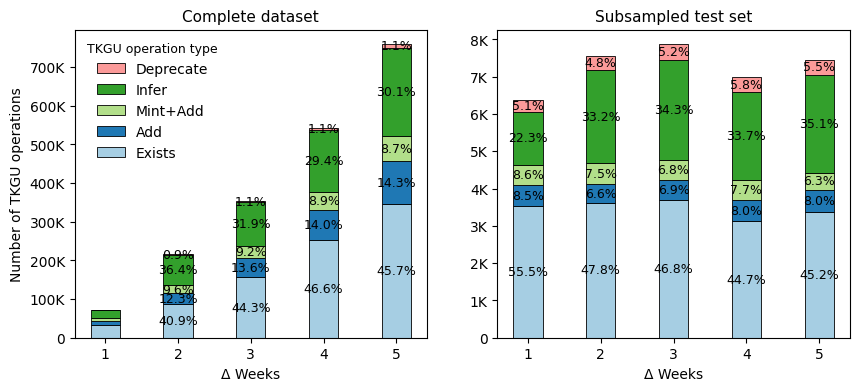

In [5]:
run_stats_on = ['complete_dataset', 'subsampled_dataset']
n_runs = len(run_stats_on)

fig, axes = plt.subplots(1, n_runs, figsize=(5 * n_runs, 4))
if n_runs == 1:
    axes = [axes]

for curr_idx, (ax, curr_run) in enumerate(zip(axes, run_stats_on)):
    df = dict_stats[curr_run]['df_preds_gt_cie'].copy()
    df_eval = filter_by_assessor(df, df_llm_assessors[curr_run])

    stacked = (
        df_eval.groupby(['delta_weeks', 'tkgu_type']).size()
        .unstack('tkgu_type', fill_value=0)
    )

    for c in tkgu_order:
        if c not in stacked.columns:
            stacked[c] = 0
    stacked = stacked[tkgu_order]
    stacked_counts = stacked.rename(columns=label_map)

    colors_bar = plt.get_cmap('Paired').colors[:len(stacked_counts.columns)]
    bar_positions = np.arange(len(stacked_counts))
    bottom = np.zeros(len(stacked_counts))

    for i, col in enumerate(stacked_counts.columns):
        values = stacked_counts[col].values
        ax.bar(bar_positions, values, bottom=bottom,
               color=colors_bar[i], edgecolor='black', linewidth=0.6,
               width=0.4, label=col)

        for j, (val, btm) in enumerate(zip(values, bottom)):
            if j == 0 and curr_idx == 0:
                continue
            if val > 0:
                total = stacked_counts.iloc[j].sum()
                percent = (val / total * 100) if total else 0.0
                ax.text(j, btm + val / 2, f'{percent:.1f}%',
                        ha='center', va='center', fontsize=9, color='black')

        bottom += values

    ax.set_title(map_key_to_title.get(curr_run, curr_run), fontsize=11)
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(stacked_counts.index, fontsize=10)
    ax.set_xlabel('\u0394 Weeks', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('Number of TKGU operations', fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8, labelsize=10)

    if curr_idx == 0:
        handles, labels_leg = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels_leg[::-1], title='TKGU operation type',
                  fontsize=10, title_fontsize=9, frameon=False)

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'))

plt.subplots_adjust(wspace=0.2)

if SAVE_DIR:
    os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(os.path.join(SAVE_DIR, 'tkgu_distribution_deltas.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(SAVE_DIR, 'tkgu_distribution_deltas.png'), bbox_inches='tight', dpi=300)
    print(f'Saved to {SAVE_DIR}')

plt.show()